In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
pd.options.display.max_columns=None
import warnings

In [2]:
df = pd.read_csv('/kaggle/input/playground-series-s5e2/sample_submission.csv')
df.head()

,id,Price
0,300000,81.411
1,300001,81.411
2,300002,81.411
3,300003,81.411
4,300004,81.411


In [3]:
test = pd.read_csv('/kaggle/input/playground-series-s5e2/test.csv')
test.head()

,id,Brand,Material,Size,Compartments,Laptop Compartment,Waterproof,Style,Color,Weight Capacity (kg)
0,300000,Puma,Leather,Small,2.0,No,No,Tote,Green,20.671147
1,300001,Nike,Canvas,Medium,7.0,No,Yes,Backpack,Green,13.564105
2,300002,Adidas,Canvas,Large,9.0,No,Yes,Messenger,Blue,11.809799
3,300003,Adidas,Nylon,Large,1.0,Yes,No,Messenger,Green,18.477036
4,300004,NaN,Nylon,Large,2.0,Yes,Yes,Tote,Black,9.907953


In [4]:
train = pd.read_csv('/kaggle/input/playground-series-s5e2/train.csv')
train.head()

,id,Brand,Material,Size,Compartments,Laptop Compartment,Waterproof,Style,Color,Weight Capacity (kg),Price
0,0,Jansport,Leather,Medium,7.0,Yes,No,Tote,Black,11.611723,112.15875
1,1,Jansport,Canvas,Small,10.0,Yes,Yes,Messenger,Green,27.078537,68.88056
2,2,Under Armour,Leather,Small,2.0,Yes,No,Messenger,Red,16.643760,39.17320
3,3,Nike,Nylon,Small,8.0,Yes,No,Messenger,Green,12.937220,80.60793
4,4,Adidas,Canvas,Medium,1.0,Yes,Yes,Messenger,Green,17.749338,86.02312


In [5]:
combined = pd.concat([df,test,train])
combined.head()

/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,id,Price,Brand,Material,Size,Compartments,Laptop Compartment,Waterproof,Style,Color,Weight Capacity (kg)
0,300000,81.411,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,300001,81.411,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,300002,81.411,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,300003,81.411,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,300004,81.411,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
combined.info()

<class 'pandas.core.frame.DataFrame'>
Index: 700000 entries, 0 to 299999
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    700000 non-null  int64  
 1   Price                 500000 non-null  float64
 2   Brand                 484068 non-null  object 
 3   Material              486040 non-null  object 
 4   Size                  489024 non-null  object 
 5   Compartments          500000 non-null  float64
 6   Laptop Compartment    487594 non-null  object 
 7   Waterproof            488139 non-null  object 
 8   Style                 486877 non-null  object 
 9   Color                 483265 non-null  object 
 10  Weight Capacity (kg)  499785 non-null  float64
dtypes: float64(3), int64(1), object(7)
memory usage: 64.1+ MB


In [7]:
combined.dtypes

id                        int64
Price                   float64
Brand                    object
Material                 object
Size                     object
Compartments            float64
Laptop Compartment       object
Waterproof               object
Style                    object
Color                    object
Weight Capacity (kg)    float64
dtype: object

In [8]:
combined.columns

Index(['id', 'Price', 'Brand', 'Material', 'Size', 'Compartments',
       'Laptop Compartment', 'Waterproof', 'Style', 'Color',
       'Weight Capacity (kg)'],
      dtype='object')

In [9]:
combined.describe().T

,count,mean,std,min,25%,50%,75%,max
id,700000.0,292856.642857,142916.756354,0.0,174999.750000,324999.500000,412499.250000,499999.0
Price,500000.0,81.411064,30.239723,15.0,69.756300,81.411000,92.262473,150.0
Compartments,500000.0,5.443296,2.889952,1.0,3.000000,5.000000,8.000000,10.0
Weight Capacity (kg),499785.0,18.015209,6.968997,5.0,12.086395,18.064996,23.985510,30.0


In [10]:
combined.corr

/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


<bound method DataFrame.corr of             id      Price         Brand Material   Size  Compartments  \
0       300000   81.41100           NaN      NaN    NaN           NaN   
1       300001   81.41100           NaN      NaN    NaN           NaN   
2       300002   81.41100           NaN      NaN    NaN           NaN   
3       300003   81.41100           NaN      NaN    NaN           NaN   
4       300004   81.41100           NaN      NaN    NaN           NaN   
...        ...        ...           ...      ...    ...           ...   
299995  299995  129.99749        Adidas  Leather  Small           9.0   
299996  299996   19.85819      Jansport  Leather  Large           6.0   
299997  299997  111.41364          Puma   Canvas  Large           9.0   
299998  299998  115.89080        Adidas    Nylon  Small           1.0   
299999  299999   26.72762  Under Armour   Canvas  Small           2.0   

       Laptop Compartment Waterproof     Style  Color  Weight Capacity (kg)  
0            

In [11]:
combined.isnull().notnull()/len('combined'*100)

,id,Price,Brand,Material,Size,Compartments,Laptop Compartment,Waterproof,Style,Color,Weight Capacity (kg)
0,0.00125,0.00125,0.00125,0.00125,0.00125,0.00125,0.00125,0.00125,0.00125,0.00125,0.00125
1,0.00125,0.00125,0.00125,0.00125,0.00125,0.00125,0.00125,0.00125,0.00125,0.00125,0.00125
2,0.00125,0.00125,0.00125,0.00125,0.00125,0.00125,0.00125,0.00125,0.00125,0.00125,0.00125
3,0.00125,0.00125,0.00125,0.00125,0.00125,0.00125,0.00125,0.00125,0.00125,0.00125,0.00125
4,0.00125,0.00125,0.00125,0.00125,0.00125,0.00125,0.00125,0.00125,0.00125,0.00125,0.00125
...,...,...,...,...,...,...,...,...,...,...,...
299995,0.00125,0.00125,0.00125,0.00125,0.00125,0.00125,0.00125,0.00125,0.00125,0.00125,0.00125
299996,0.00125,0.00125,0.00125,0.00125,0.00125,0.00125,0.00125,0.00125,0.00125,0.00125,0.00125
299997,0.00125,0.00125,0.00125,0.00125,0.00125,0.00125,0.00125,0.00125,0.00125,0.00125,0.00125
299998,0.00125,0.00125,0.00125,0.00125,0.00125,0.00125,0.00125,0.00125,0.00125,0.00125,0.00125


In [12]:
combined.shape

(700000, 11)

<Axes: >

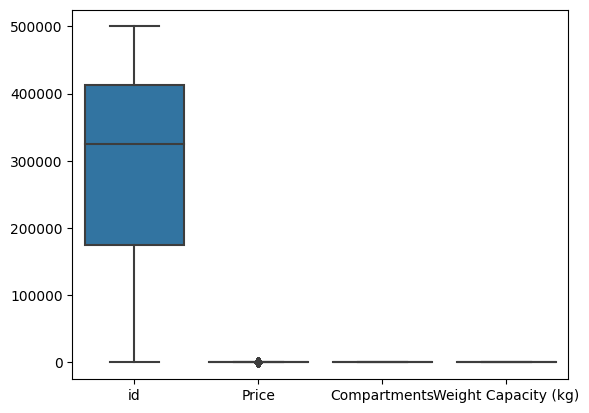

In [13]:
sns.boxplot(combined)

<Axes: >

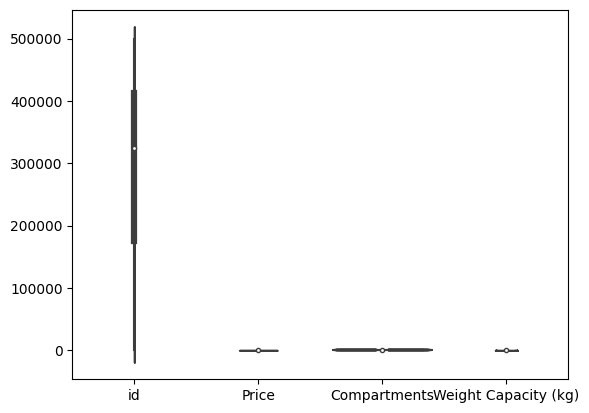

In [14]:
sns.violinplot(combined)

<Axes: >

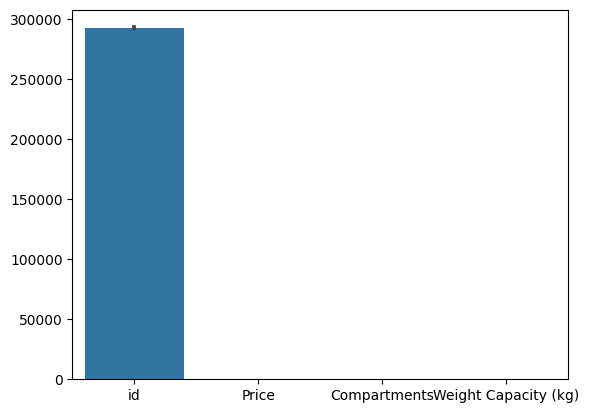

In [15]:
sns.barplot(combined)

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

<Axes: ylabel='Density'>

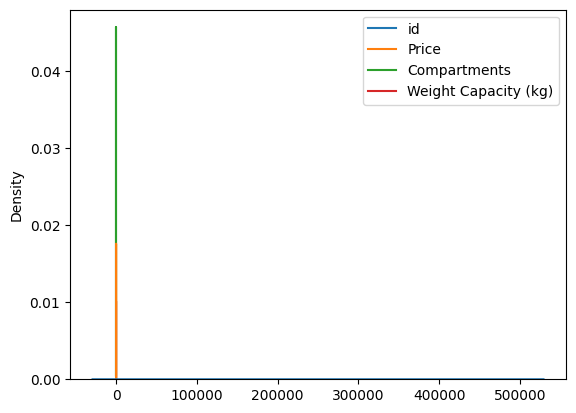

In [16]:
sns.kdeplot(combined)

<Axes: >

/usr/local/lib/python3.10/dist-packages/IPython/core/events.py:89: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


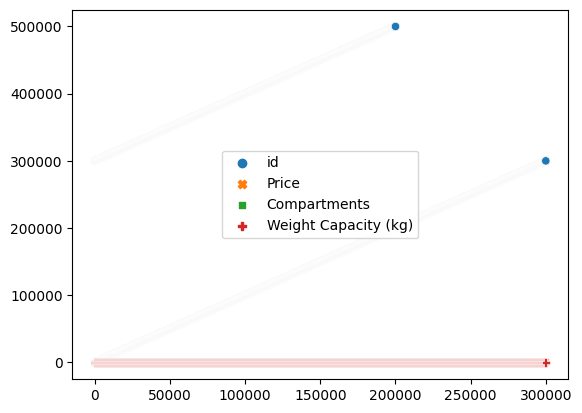

In [17]:
sns.scatterplot(combined)

In [18]:
cat_cols = combined.select_dtypes(include='object')

In [19]:
for i in cat_cols :
    (cat_cols[i].value_counts())
    print(i)
    print(''*50)

Brand

Material

Size

Laptop Compartment

Waterproof

Style

Color



In [20]:
num_cols = combined.select_dtypes(include='number')

In [21]:
for i in num_cols:
    (num_cols[i].value_counts())
    print(i)
    print(''*50)

id

Price

Compartments

Weight Capacity (kg)



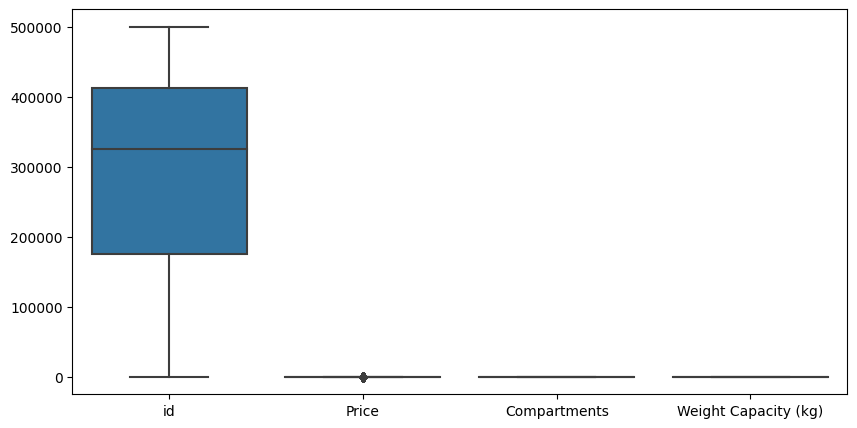

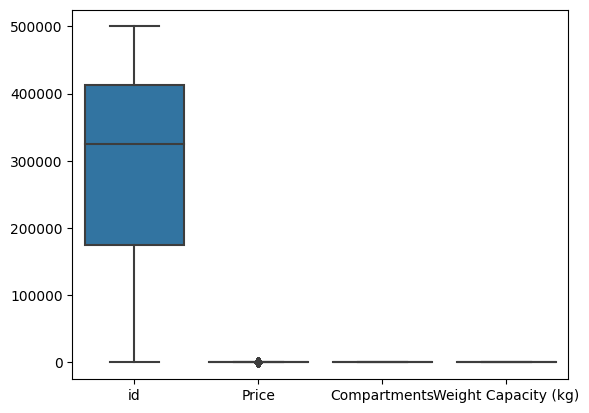

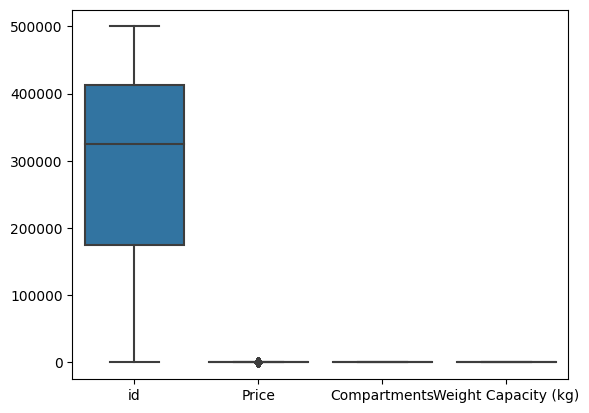

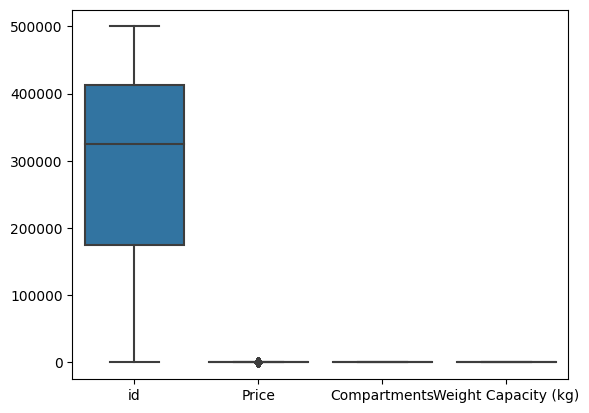

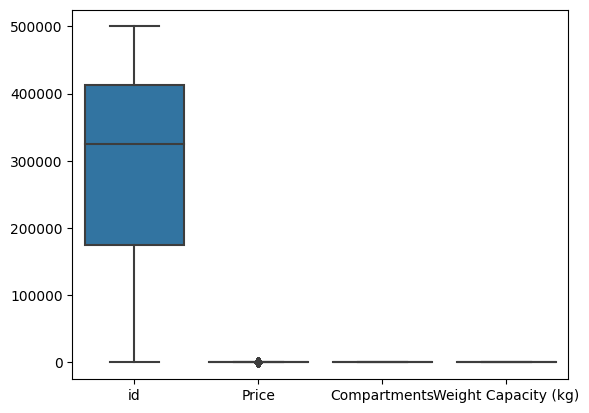

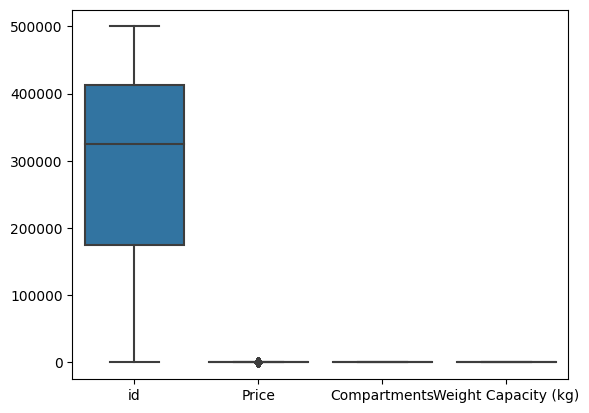

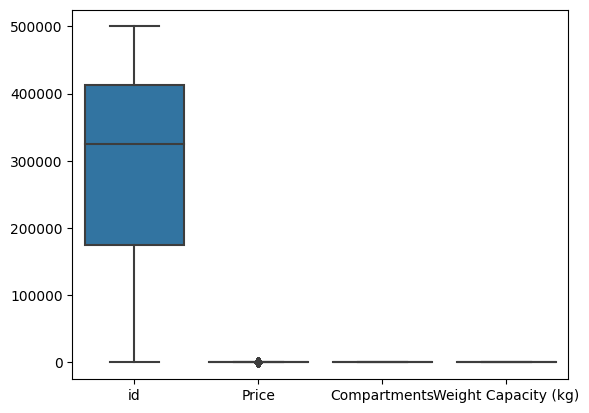

In [22]:
x = 1
plt.figure(figsize=(10,5))
cat_cols = combined.select_dtypes(include='object')
for i in cat_cols:
    sns.boxplot(data=combined)
    print('\n')
    plt.show()

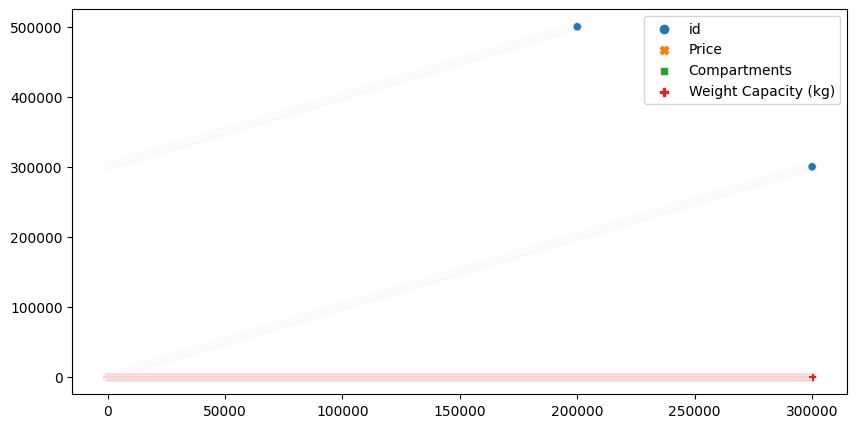

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


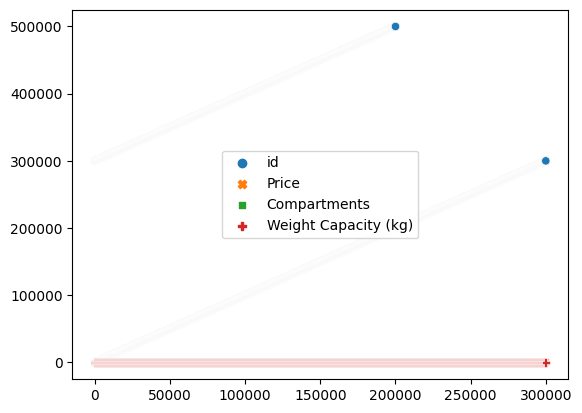

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


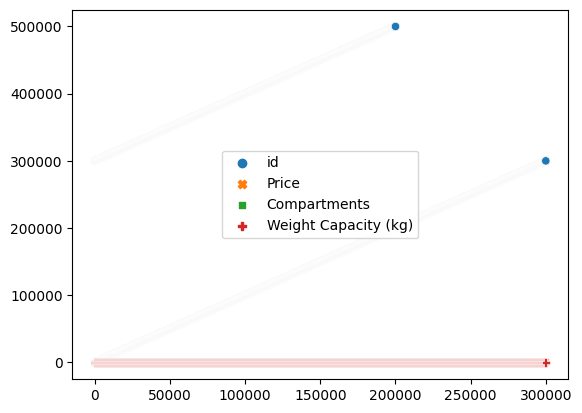

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


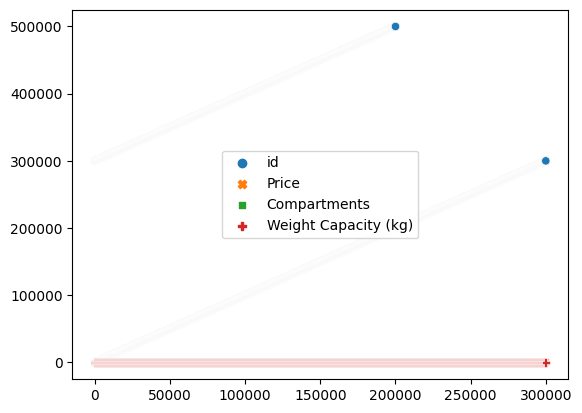

In [24]:
x = 1
plt.figure(figsize=(10,5))
num_cols = combined.select_dtypes(include='number')
for i in num_cols:
    sns.scatterplot(data=combined)
    print('\n')
    plt.show()

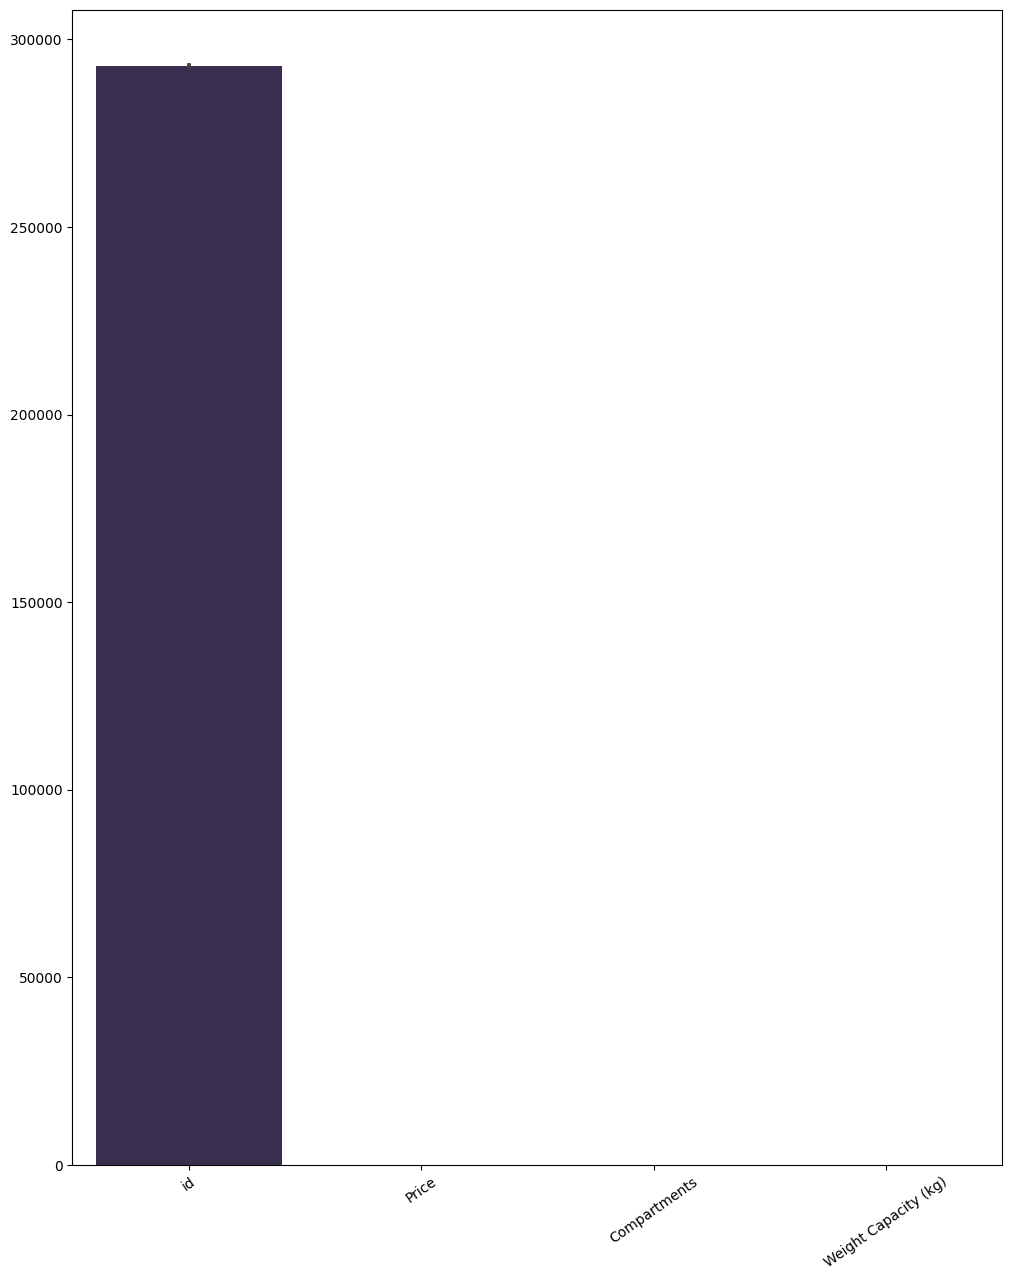

In [25]:
plt.figure(figsize=(12,15))
sns.barplot(data=combined,palette='mako');
plt.xticks(rotation=35);
plt.show() 

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

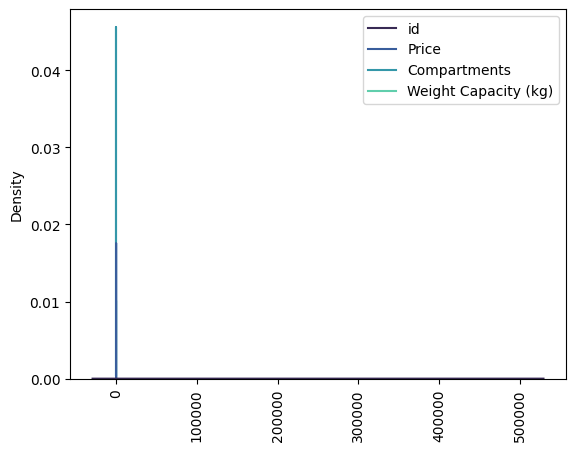

In [26]:
sns.kdeplot(data=combined,palette='mako');
plt.xticks(rotation=90)
plt.show() 

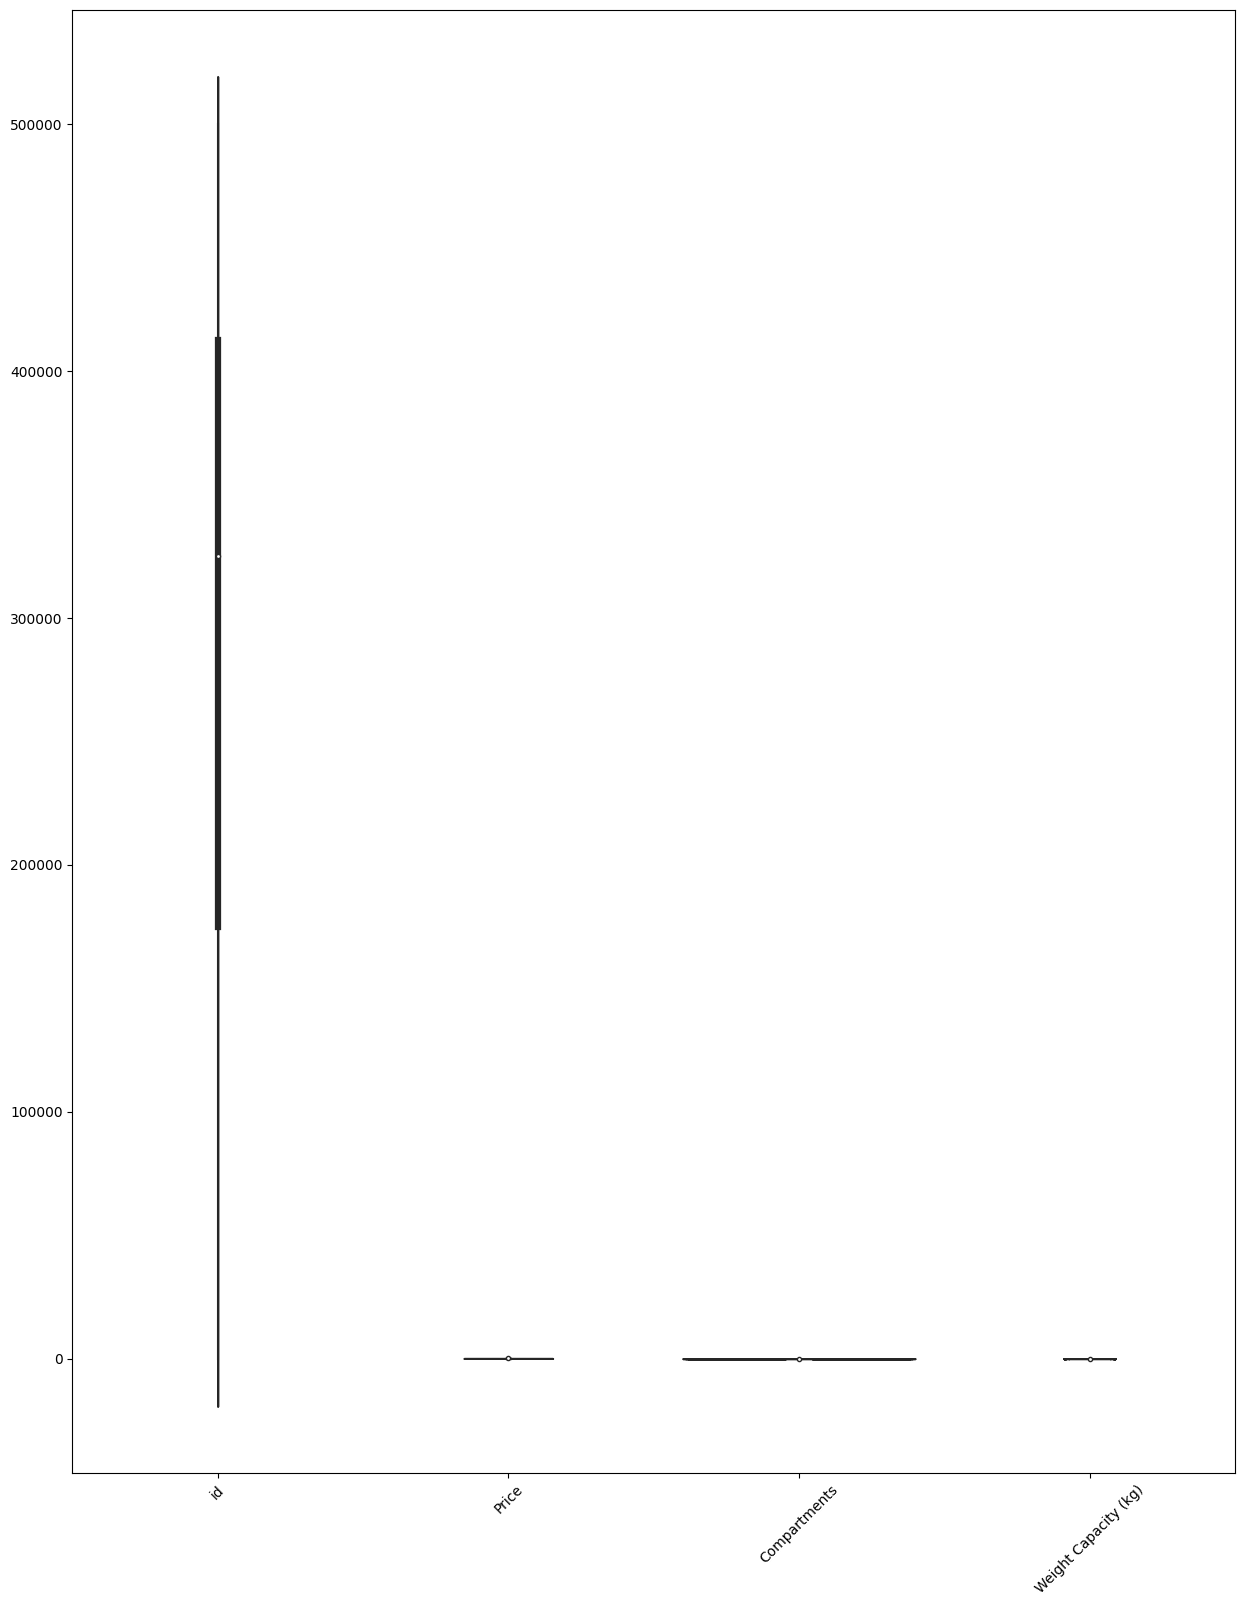

In [27]:
plt.figure(figsize=(15,19))
sns.violinplot(data=combined,palette='mako');
plt.xticks(rotation=45);
plt.show()